# Modul

In [ ]:
# Import Library

import numpy as np
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import math
from sklearn.metrics import mean_squared_error
from numpy import array
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats import pearsonr
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.svm import SVR
from xgboost import XGBClassifier

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import mean_squared_log_error
from numpy import array
from scipy.stats import kurtosis, skew

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/FauzanTrisuladana/content/refs/heads/master/bikesharing_day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
# change data format
df_ori = df
df_ori['date'] = pd.to_datetime(df_ori['dteday'])
df_ori['cnt'].iloc[:10]

,cnt
0,985
1,801
2,1349
3,1562
4,1600
5,1606
6,1510
7,959
8,822
9,1321


In [ ]:
# Function Definition Sliding Window

def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out

        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break

        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[out_end_ix - 1, -1]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [ ]:
# Function Definition Statistic Feature

def stats_features(input_data):
    inp = list()
    for i in range(len(input_data)):
        inp2=list()
        inp2=input_data[i]
        min=float(np.min(inp2))
        max=float(np.max(inp2))
        diff=(max-min)
        std=float(np.std(inp2))
        mean=float(np.mean(inp2))
        median=float(np.median(inp2))
        kurt=float(kurtosis(inp2))
        sk=float(skew(inp2))
        inp2=np.append(inp2,min)
        inp2=np.append(inp2,max)
        inp2=np.append(inp2,diff)
        inp2=np.append(inp2,std)
        inp2=np.append(inp2,mean)
        inp2=np.append(inp2,median)
        inp2=np.append(inp2,kurt)
        inp2=np.append(inp2,sk)

        #print(list(inp2))
        inp=np.append(inp,inp2)

    inp=inp.reshape(len(input_data),-1)

    #print(inp)
    return inp

In [ ]:
# Preprocessing

df_X = df_ori[['cnt','cnt']]
in_seq = df_X.astype(float).values
#out_seq = df_y.astype(float).values

#in_seq1 = in_seq.reshape(in_seq.shape[0], in_seq.shape[1])
#out_seq = out_seq.reshape((len(out_seq), 1))

#from numpy import hstack
#dataset = hstack((in_seq1, out_seq))

n_steps_in, n_steps_out = 7, 1
X, y = split_sequences(in_seq, n_steps_in, n_steps_out)

n_input = X.shape[1] * X.shape[2]
X = X.reshape((X.shape[0], n_input))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle = False)
X_train = stats_features(X_train)
X_test = stats_features(X_test)

In [ ]:
in_seq

array([[ 985.,  985.],
       [ 801.,  801.],
       [1349., 1349.],
       ...,
       [1341., 1341.],
       [1796., 1796.],
       [2729., 2729.]])

In [ ]:
X

array([[ 985.,  801., 1349., ..., 1600., 1606., 1510.],
       [ 801., 1349., 1562., ..., 1606., 1510.,  959.],
       [1349., 1562., 1600., ..., 1510.,  959.,  822.],
       ...,
       [1749., 1787.,  920., ...,  441., 2114., 3095.],
       [1787.,  920., 1013., ..., 2114., 3095., 1341.],
       [ 920., 1013.,  441., ..., 3095., 1341., 1796.]])

In [ ]:
X.shape

(724, 7)

In [ ]:
X[0]

array([ 985.,  801., 1349., 1562., 1600., 1606., 1510.])

In [ ]:
y[0]

np.float64(959.0)

In [ ]:
# Dataframe from Time Series Analysis

df_new=df_ori[['date','cnt']]
df_new.set_index('date')

,cnt
date,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600
...,...
2012-12-27,2114
2012-12-28,3095
2012-12-29,1341


/tmp/ipykernel_2231/202835424.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left',  fontsize=15)


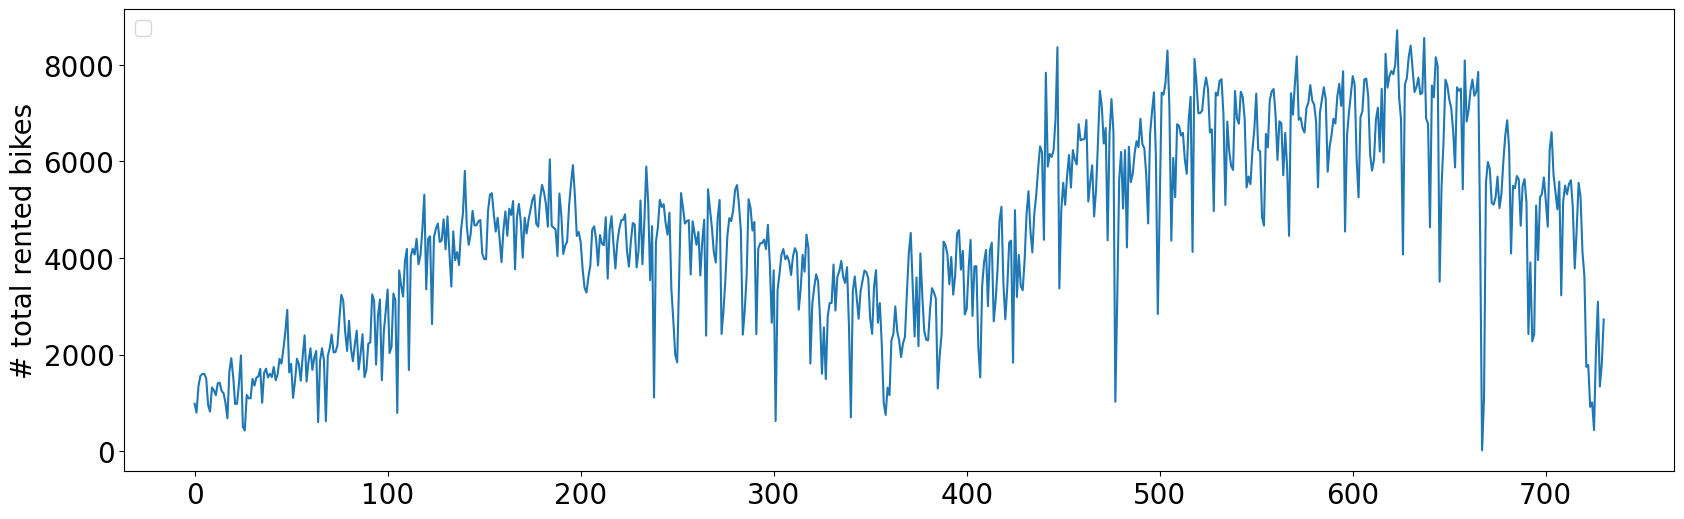

In [ ]:
# Visualization Total Bike Rental

fig1 = plt.figure(figsize=(20,6))
plt.plot(df_new['cnt'])
#plt.xlabel('Time t',  fontsize=20)
#because we use temperature data, so that the y axis is temperature
plt.ylabel('# total rented bikes',  fontsize=20)
plt.legend(loc='upper left',  fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [ ]:
# Neural Network Model

def mlp (X_train, X_test, y_train, y_test):
    # mlp = multilayer perceptron / neural network for regression.
    # to setup parameter, please refer to = https://scikit-learn.org/stable/modules/generated/sklearn.neural_ne
    mlp_model = MLPRegressor(random_state=42)
    mlp_model = MLPRegressor(hidden_layer_sizes=(100,100, ), max_iter=1000, random_state=42)
    # the model learning from training data
    mlp_model.fit(X_train, y_train)
    # get the prediction output
    y_pred = mlp_model.predict(X_test)
    y_pred = np.round(y_pred, 0)

    # get the root mean square error between prediction and real test data
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    # get the pearson correlation
    corr, p_value = pearsonr(y_test, y_pred)
    # returning the output of RMSE, corr, and prediction result
    return rmse, corr, y_pred

In [ ]:
# K-Nearest Neighbors Model

def knn (X_train, X_test, y_train, y_test):
    #k nearest neighbor for regression.
    #to setup the parameter please refer to : https://scikit-learn.org/stable/modules/generated/sklearn.neighb
    knn_model = KNeighborsRegressor()
    #the model is learning from training data
    knn_model.fit(X_train, y_train)
    #get the prediction output
    y_pred = knn_model.predict(X_test)
    y_pred = np.round(y_pred, 0)
    #get the root mean square error between prediction and real test data
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    #get the pearson correlation
    corr, p_value = pearsonr(y_test, y_pred)
    #returning the output of RMSE, corr, and prediction result
    return rmse, corr, y_pred

In [ ]:
# Decision Tree Model

def dt (X_train, X_test, y_train, y_test):
    model= DecisionTreeRegressor(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred = np.round(y_pred, 0)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    #get the pearson correlation
    corr, p_value = pearsonr(y_test, y_pred)
    #returning the output of RMSE, corr, and prediction result
    return rmse, corr, y_pred

In [ ]:
# Random Forest Model

def rf (X_train, X_test, y_train, y_test):
    model=RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred = np.round(y_pred, 0)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    #get the pearson correlation
    corr, p_value = pearsonr(y_test, y_pred)
    #returning the output of RMSE, corr, and prediction result
    return rmse, corr, y_pred

In [ ]:
# Call the Machine Learning Model Function

#calling the function mlp.
#returning rmse, pearson correlation, and prediction output
rmse_mlp, corr_mlp, y_pred_mlp = mlp(X_train, X_test, y_train, y_test)

#calling the function knn
#returning rmse, pearson correlation, and prediction output
rmse_knn, corr_knn, y_pred_knn = knn(X_train, X_test, y_train, y_test)
rmse_dt, corr_dt, y_pred_dt = dt(X_train, X_test, y_train, y_test)

#rmse_svm, corr_svm, y_pred_svm = svm(X_train, X_test, y_train, y_test)
rmse_rf, corr_rf, y_pred_rf = rf(X_train, X_test, y_train, y_test)

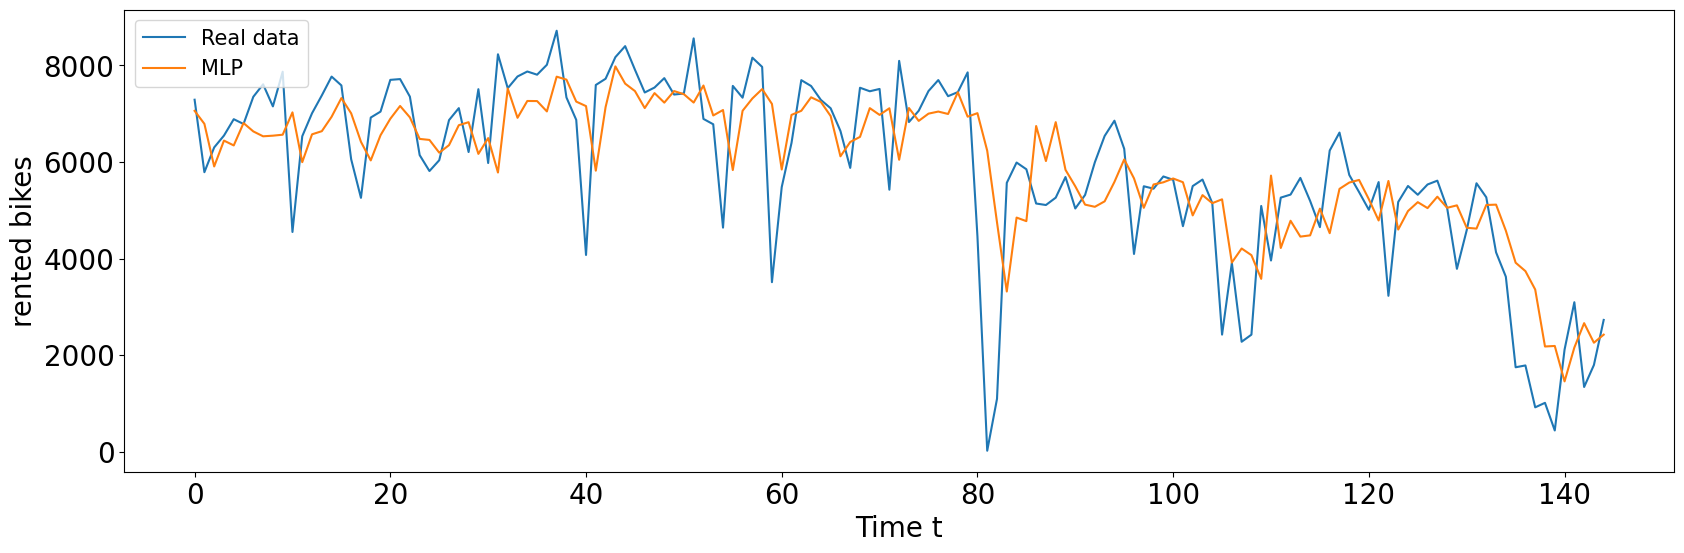

In [ ]:
# Visualization

fig1 = plt.figure(figsize=(20,6))
# plotting the result
# because the total number of test is data is high, so we just print the first 100 data
# y_test[0:100] get the first 100 data from y_test or real test data.
# y_pred_mlp is the prediction result from MLP
# y_pred_knn is the prediction result from KNN

plt.plot(y_test, label='Real data')
# plt.plot(y_pred_knn, label='KNN')
# plt.plot(y_pred_dt, label='DT')
# plt.plot(y_pred_rf, label='RF')
plt.plot(y_pred_mlp, label='MLP')

#title
# pyplot.title('First 100 Test Data')
# the x axis is timestamp, with interval 1 day
plt.xlabel('Time t', fontsize=20)
# because we use total rented bikes, so that the y axis is rented bikes
plt.ylabel('rented bikes', fontsize=20)
plt.legend(loc='upper left', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

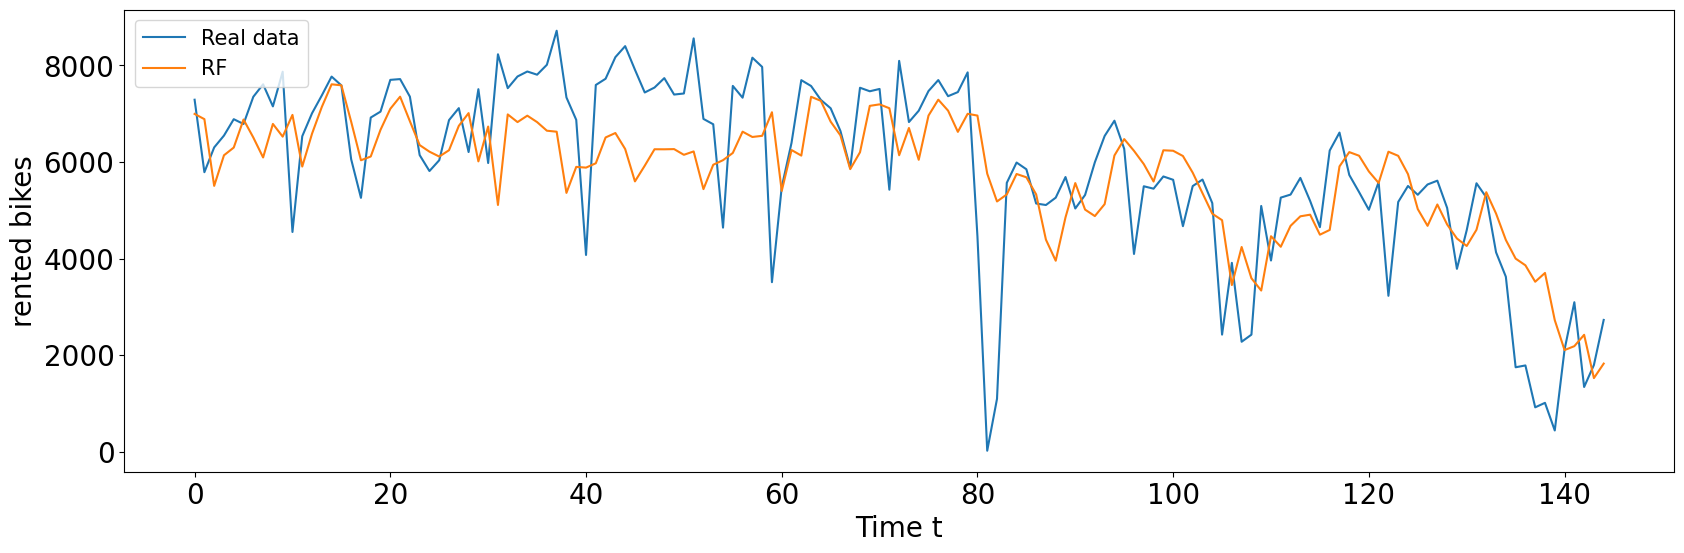

In [ ]:
# Visualization

fig1 = plt.figure(figsize=(20,6))
# plotting the result
# because the total number of test is data is high, so we just print the first 100 data
# y_test[0:100] get the first 100 data from y_test or real test data.
# y_pred_mlp is the prediction result from MLP
# y_pred_knn is the prediction result from KNN

plt.plot(y_test, label='Real data')
# plt.plot(y_pred_knn, label='KNN')
# plt.plot(y_pred_dt, label='DT')
plt.plot(y_pred_rf, label='RF')
# plt.plot(y_pred_mlp, label='MLP')

#title
# pyplot.title('First 100 Test Data')
# the x axis is timestamp, with interval 1 day
plt.xlabel('Time t', fontsize=20)
# because we use total rented bikes, so that the y axis is rented bikes
plt.ylabel('rented bikes', fontsize=20)
plt.legend(loc='upper left', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

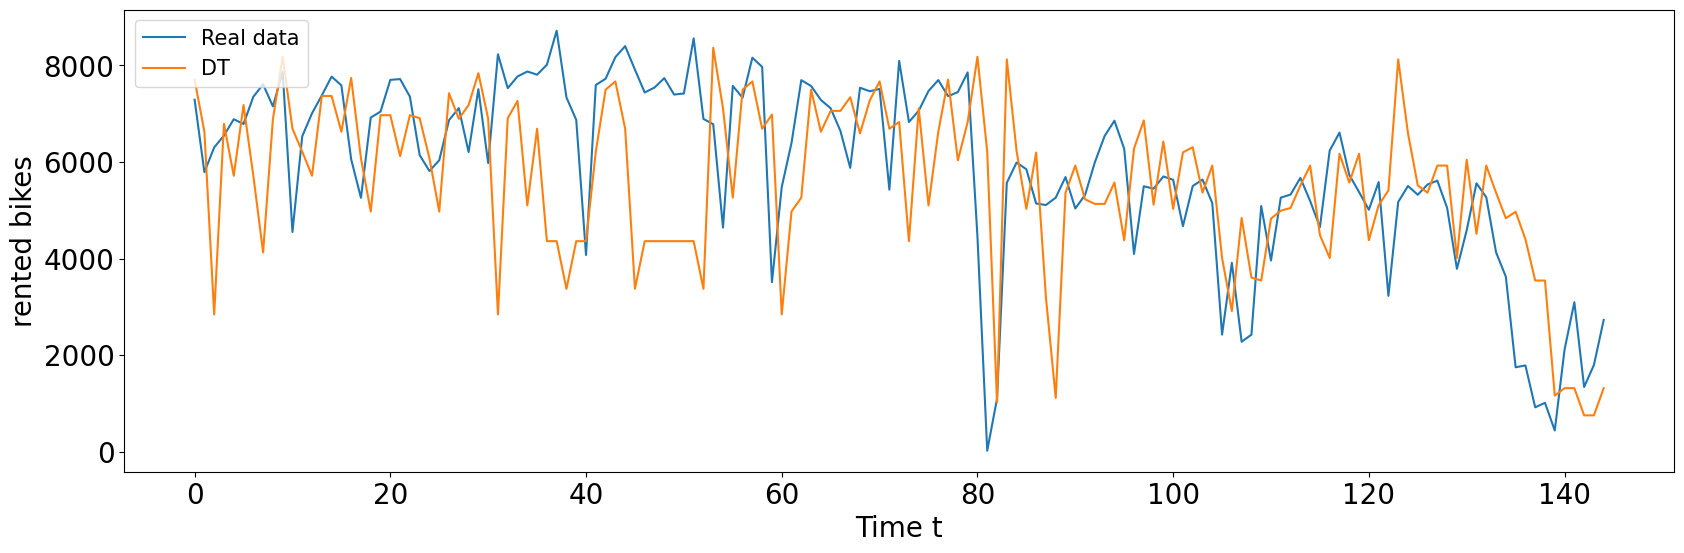

In [ ]:
# Visualization

fig1 = plt.figure(figsize=(20,6))
# plotting the result
# because the total number of test is data is high, so we just print the first 100 data
# y_test[0:100] get the first 100 data from y_test or real test data.
# y_pred_mlp is the prediction result from MLP
# y_pred_knn is the prediction result from KNN

plt.plot(y_test, label='Real data')
# plt.plot(y_pred_knn, label='KNN')
plt.plot(y_pred_dt, label='DT')
# plt.plot(y_pred_rf, label='RF')
# plt.plot(y_pred_mlp, label='MLP')

#title
# pyplot.title('First 100 Test Data')
# the x axis is timestamp, with interval 1 day
plt.xlabel('Time t', fontsize=20)
# because we use total rented bikes, so that the y axis is rented bikes
plt.ylabel('rented bikes', fontsize=20)
plt.legend(loc='upper left', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

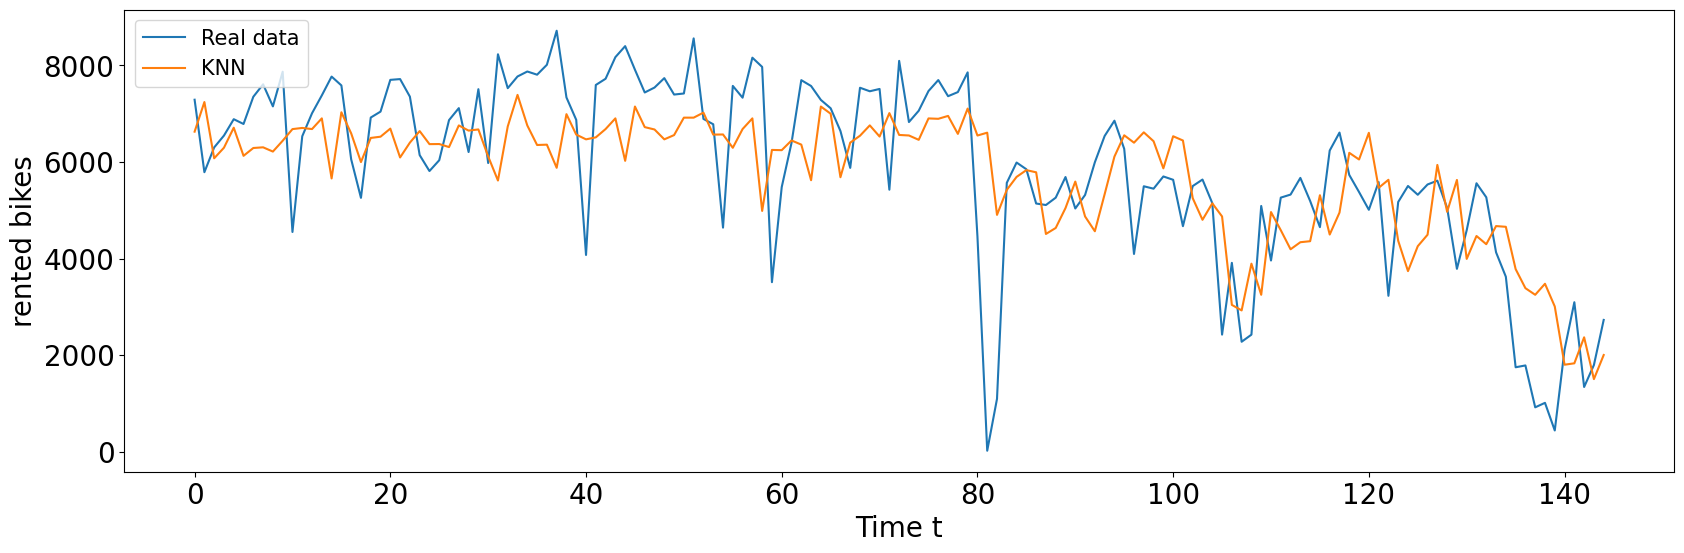

In [ ]:
# Visualization

fig1 = plt.figure(figsize=(20,6))
# plotting the result
# because the total number of test is data is high, so we just print the first 100 data
# y_test[0:100] get the first 100 data from y_test or real test data.
# y_pred_mlp is the prediction result from MLP
# y_pred_knn is the prediction result from KNN

plt.plot(y_test, label='Real data')
plt.plot(y_pred_knn, label='KNN')
# plt.plot(y_pred_dt, label='DT')
# plt.plot(y_pred_rf, label='RF')
# plt.plot(y_pred_mlp, label='MLP')

#title
# pyplot.title('First 100 Test Data')
# the x axis is timestamp, with interval 1 day
plt.xlabel('Time t', fontsize=20)
# because we use total rented bikes, so that the y axis is rented bikes
plt.ylabel('rented bikes', fontsize=20)
plt.legend(loc='upper left', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [ ]:
# Model Evaluation

# print out the RMSE , pearson correlation coefficient for MLP and KNN
# low RMSE is better
# high pearson correlation coefficient is better.
print('______________________')
print('MLP')
print('RMSE : %.3f' %rmse_mlp)
print('Pearson correlation coefficient: %.3f' %corr_mlp)
print('______________________')
print('KNN')
print('RMSE : %.3f' %rmse_knn)
print('Pearson correlation coefficient: %.3f' %corr_knn)
print('______________________')
print('DT')
print('RMSE : %.3f' %rmse_dt)
print('Pearson correlation coefficient: %.3f' %corr_dt)
print('______________________')
print('RF')
print('RMSE : %.3f' %rmse_rf)
print('Pearson correlation coefficient: %.3f' %corr_rf)

______________________
MLP
RMSE : 1243.150
Pearson correlation coefficient: 0.751
______________________
KNN
RMSE : 1357.710
Pearson correlation coefficient: 0.696
______________________
DT
RMSE : 1854.465
Pearson correlation coefficient: 0.484
______________________
RF
RMSE : 1324.452
Pearson correlation coefficient: 0.716


# Tugas

In [ ]:
import numpy as np
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import math
from sklearn.metrics import mean_squared_error
from numpy import array
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats import pearsonr
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.svm import SVR
from xgboost import XGBClassifier

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import mean_squared_log_error
from numpy import array
from scipy.stats import kurtosis, skew

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/FauzanTrisuladana/content/refs/heads/master/TSLA.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [ ]:
# Function Definition Sliding Window

def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out

        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break

        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[out_end_ix - 1, -1]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [ ]:
# Function Definition Statistic Feature

def stats_features(input_data):
    inp = list()
    for i in range(len(input_data)):
        inp2=list()
        inp2=input_data[i]
        min=float(np.min(inp2))
        max=float(np.max(inp2))
        diff=(max-min)
        std=float(np.std(inp2))
        mean=float(np.mean(inp2))
        median=float(np.median(inp2))
        kurt=float(kurtosis(inp2))
        sk=float(skew(inp2))
        inp2=np.append(inp2,min)
        inp2=np.append(inp2,max)
        inp2=np.append(inp2,diff)
        inp2=np.append(inp2,std)
        inp2=np.append(inp2,mean)
        inp2=np.append(inp2,median)
        inp2=np.append(inp2,kurt)
        inp2=np.append(inp2,sk)

        #print(list(inp2))
        inp=np.append(inp,inp2)

    inp=inp.reshape(len(input_data),-1)

    #print(inp)
    return inp

In [ ]:
# Neural Network Model

def mlp (X_train, X_test, y_train, y_test):
    # mlp = multilayer perceptron / neural network for regression.
    # to setup parameter, please refer to = https://scikit-learn.org/stable/modules/generated/sklearn.neural_ne
    mlp_model = MLPRegressor(random_state=42)
    mlp_model = MLPRegressor(hidden_layer_sizes=(100,100, ), max_iter=1000, random_state=42)
    # the model learning from training data
    mlp_model.fit(X_train, y_train)
    # get the prediction output
    y_pred = mlp_model.predict(X_test)
    y_pred = np.round(y_pred, 0)

    # get the root mean square error between prediction and real test data
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    # get the pearson correlation
    corr, p_value = pearsonr(y_test, y_pred)
    # returning the output of RMSE, corr, and prediction result
    return rmse, corr, y_pred

In [ ]:
# K-Nearest Neighbors Model

def knn (X_train, X_test, y_train, y_test):
    #k nearest neighbor for regression.
    #to setup the parameter please refer to : https://scikit-learn.org/stable/modules/generated/sklearn.neighb
    knn_model = KNeighborsRegressor()
    #the model is learning from training data
    knn_model.fit(X_train, y_train)
    #get the prediction output
    y_pred = knn_model.predict(X_test)
    y_pred = np.round(y_pred, 0)
    #get the root mean square error between prediction and real test data
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    #get the pearson correlation
    corr, p_value = pearsonr(y_test, y_pred)
    #returning the output of RMSE, corr, and prediction result
    return rmse, corr, y_pred

In [ ]:
# Decision Tree Model

def dt (X_train, X_test, y_train, y_test):
    model= DecisionTreeRegressor(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred = np.round(y_pred, 0)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    #get the pearson correlation
    corr, p_value = pearsonr(y_test, y_pred)
    #returning the output of RMSE, corr, and prediction result
    return rmse, corr, y_pred


In [ ]:
# Random Forest Model

def rf (X_train, X_test, y_train, y_test):
    model=RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred = np.round(y_pred, 0)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    #get the pearson correlation
    corr, p_value = pearsonr(y_test, y_pred)
    #returning the output of RMSE, corr, and prediction result
    return rmse, corr, y_pred

## Nomer 2

In [ ]:
# change data format
df_ori = df
df_ori['Date'] = pd.to_datetime(df_ori['Date'])
df_ori['Close'].iloc[:10]

,Close
0,23.889999
1,23.830000
2,21.959999
3,19.200001
4,16.110001
5,15.800000
6,17.459999
7,17.400000
8,17.049999
9,18.139999


In [ ]:
# Preprocessing

df_X = df_ori[['Close','Close']]
in_seq = df_X.astype(float).values
#out_seq = df_y.astype(float).values

#in_seq1 = in_seq.reshape(in_seq.shape[0], in_seq.shape[1])
#out_seq = out_seq.reshape((len(out_seq), 1))

#from numpy import hstack
#dataset = hstack((in_seq1, out_seq))

n_steps_in, n_steps_out = 7, 2
X, y = split_sequences(in_seq, n_steps_in, n_steps_out)

n_input = X.shape[1] * X.shape[2]
X = X.reshape((X.shape[0], n_input))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle = False)
X_train = stats_features(X_train)
X_test = stats_features(X_test)

In [ ]:
in_seq

array([[ 23.889999,  23.889999],
       [ 23.83    ,  23.83    ],
       [ 21.959999,  21.959999],
       ...,
       [640.809998, 640.809998],
       [650.570007, 650.570007],
       [780.      , 780.      ]])

In [ ]:
X

array([[ 23.889999,  23.83    ,  21.959999, ...,  16.110001,  15.8     ,
         17.459999],
       [ 23.83    ,  21.959999,  19.200001, ...,  15.8     ,  17.459999,
         17.4     ],
       [ 21.959999,  19.200001,  16.110001, ...,  17.459999,  17.4     ,
         17.049999],
       ...,
       [510.5     , 547.200012, 569.559998, ..., 564.820007, 558.02002 ,
        566.900024],
       [547.200012, 569.559998, 572.200012, ..., 558.02002 , 566.900024,
        580.98999 ],
       [569.559998, 572.200012, 564.820007, ..., 566.900024, 580.98999 ,
        640.809998]])

In [ ]:
X.shape

(2408, 7)

In [ ]:
X[0]

array([23.889999, 23.83    , 21.959999, 19.200001, 16.110001, 15.8     ,
       17.459999])

In [ ]:
y[0]

np.float64(17.049999)

In [ ]:
# Dataframe from Time Series Analysis

df_new=df_ori[['Date','Close']]
df_new.set_index('Date')

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001
...,...
2020-01-28,566.900024
2020-01-29,580.989990
2020-01-30,640.809998


/tmp/ipykernel_2231/1258753815.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left',  fontsize=15)


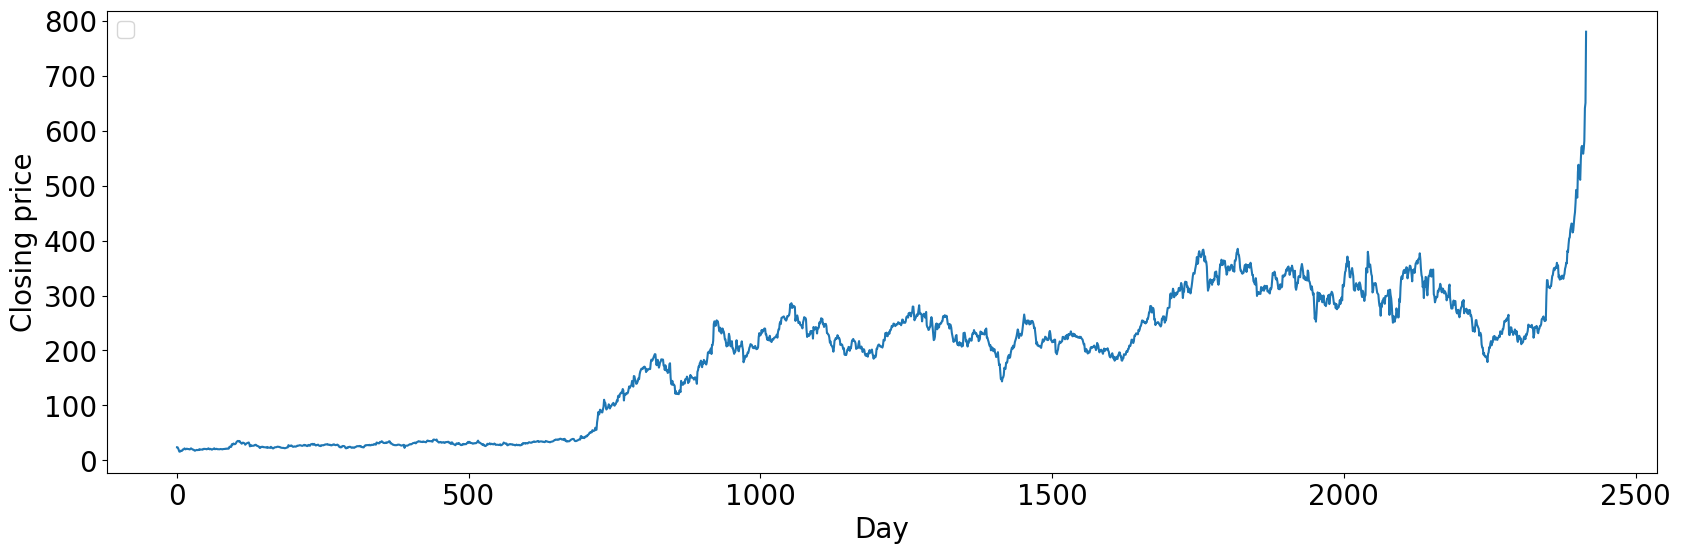

In [ ]:
# Visualization Total Bike Rental

fig1 = plt.figure(figsize=(20,6))
plt.plot(df_new['Close'])
plt.xlabel('Day',  fontsize=20)
plt.ylabel('Closing price',  fontsize=20)
plt.legend(loc='upper left',  fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [ ]:
# Call the Machine Learning Model Function

#calling the function mlp.
#returning rmse, pearson correlation, and prediction output
rmse_mlp, corr_mlp, y_pred_mlp = mlp(X_train, X_test, y_train, y_test)

#calling the function knn
#returning rmse, pearson correlation, and prediction output
rmse_knn, corr_knn, y_pred_knn = knn(X_train, X_test, y_train, y_test)
rmse_dt, corr_dt, y_pred_dt = dt(X_train, X_test, y_train, y_test)

#rmse_svm, corr_svm, y_pred_svm = svm(X_train, X_test, y_train, y_test)
rmse_rf, corr_rf, y_pred_rf = rf(X_train, X_test, y_train, y_test)

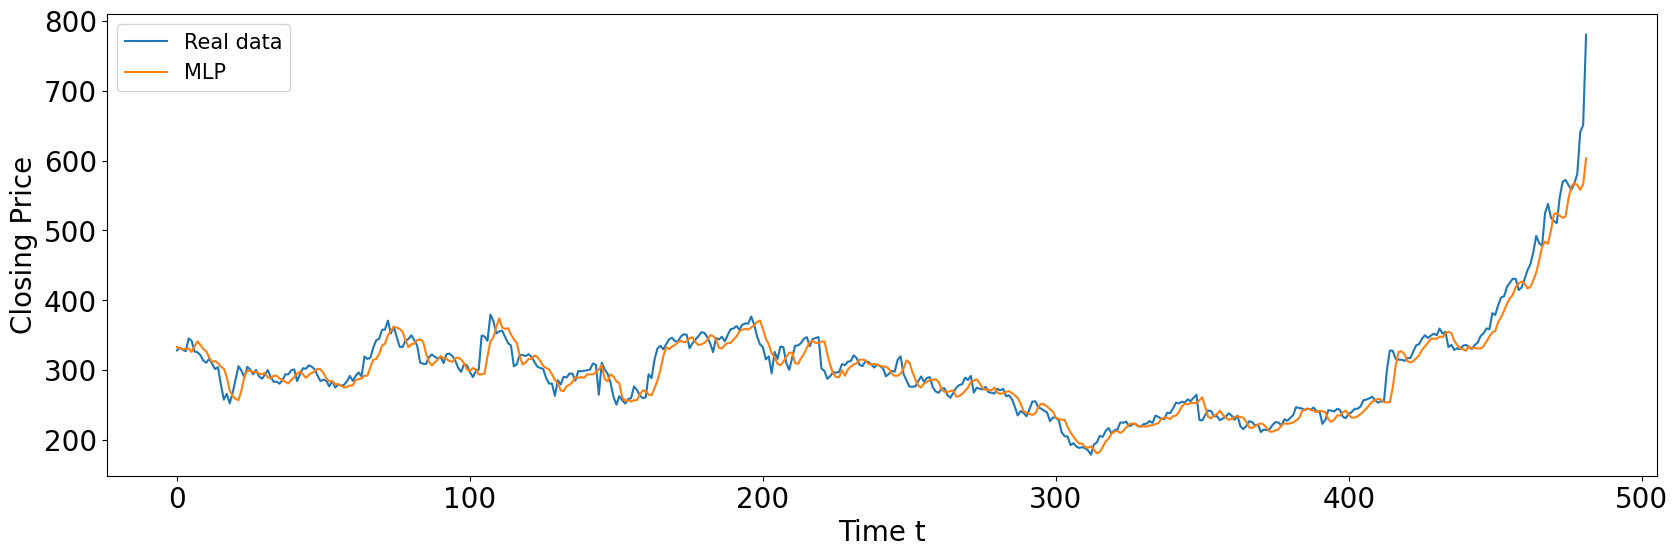

In [ ]:
# Visualization

fig1 = plt.figure(figsize=(20,6))
# plotting the result
# because the total number of test is data is high, so we just print the first 100 data
# y_test[0:100] get the first 100 data from y_test or real test data.
# y_pred_mlp is the prediction result from MLP
# y_pred_knn is the prediction result from KNN

plt.plot(y_test, label='Real data')
# plt.plot(y_pred_knn, label='KNN')
# plt.plot(y_pred_dt, label='DT')
# plt.plot(y_pred_rf, label='RF')
plt.plot(y_pred_mlp, label='MLP')

#title
# pyplot.title('First 100 Test Data')
# the x axis is timestamp, with interval 1 day
plt.xlabel('Time t', fontsize=20)
plt.ylabel('Closing Price', fontsize=20)
plt.legend(loc='upper left', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

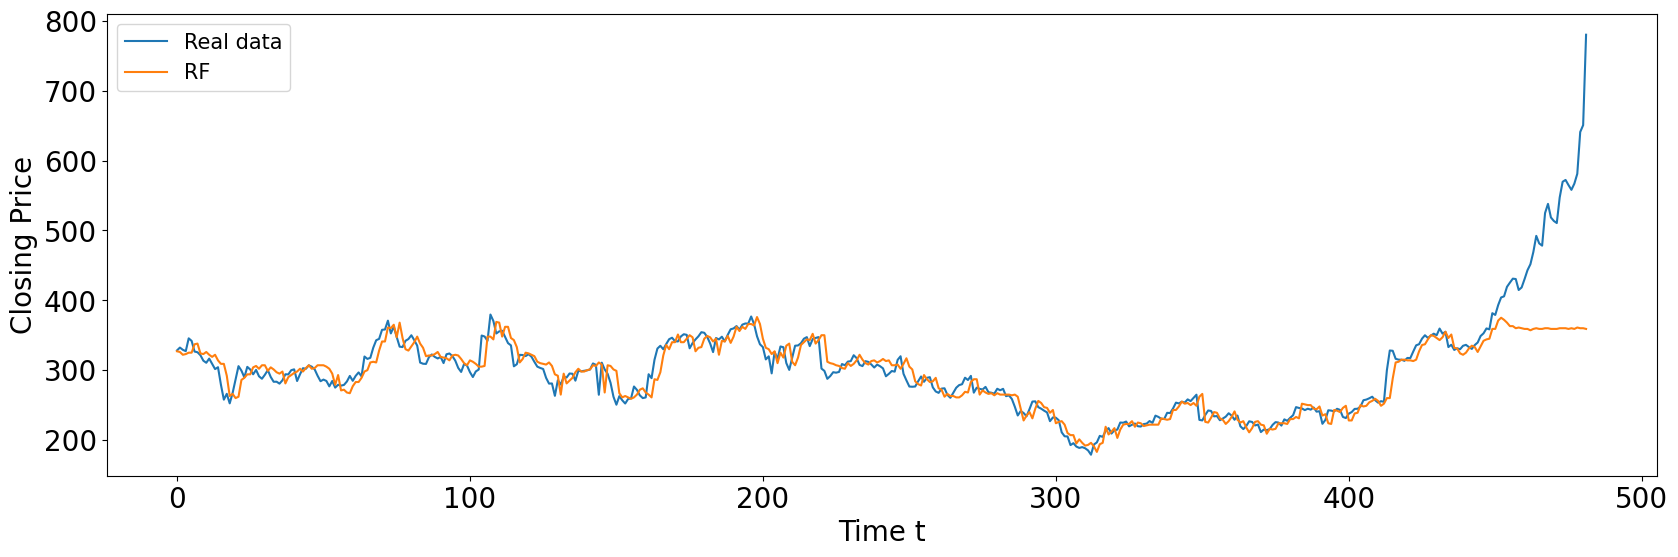

In [ ]:
# Visualization

fig1 = plt.figure(figsize=(20,6))
# plotting the result
# because the total number of test is data is high, so we just print the first 100 data
# y_test[0:100] get the first 100 data from y_test or real test data.
# y_pred_mlp is the prediction result from MLP
# y_pred_knn is the prediction result from KNN

plt.plot(y_test, label='Real data')
# plt.plot(y_pred_knn, label='KNN')
# plt.plot(y_pred_dt, label='DT')
plt.plot(y_pred_rf, label='RF')
# plt.plot(y_pred_mlp, label='MLP')

#title
# pyplot.title('First 100 Test Data')
# the x axis is timestamp, with interval 1 day
plt.xlabel('Time t', fontsize=20)
plt.ylabel('Closing Price', fontsize=20)
plt.legend(loc='upper left', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

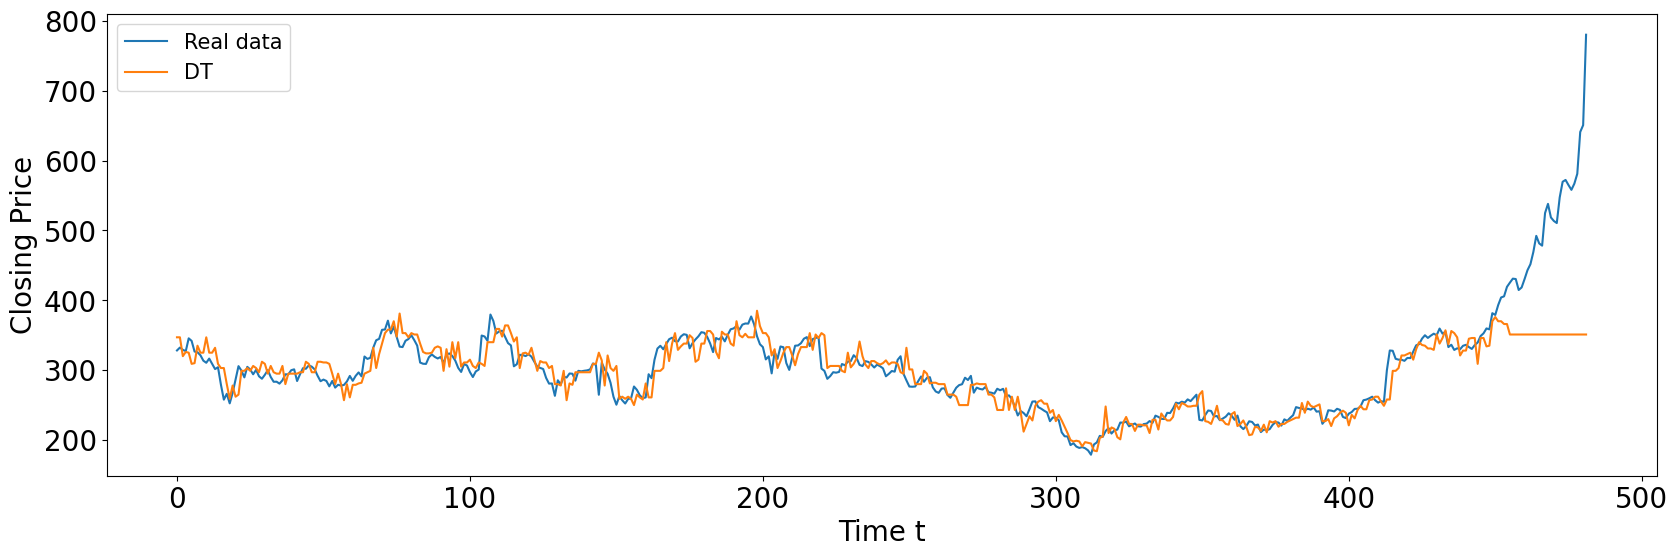

In [ ]:
# Visualization

fig1 = plt.figure(figsize=(20,6))
# plotting the result
# because the total number of test is data is high, so we just print the first 100 data
# y_test[0:100] get the first 100 data from y_test or real test data.
# y_pred_mlp is the prediction result from MLP
# y_pred_knn is the prediction result from KNN

plt.plot(y_test, label='Real data')
# plt.plot(y_pred_knn, label='KNN')
plt.plot(y_pred_dt, label='DT')
# plt.plot(y_pred_rf, label='RF')
# plt.plot(y_pred_mlp, label='MLP')

#title
# pyplot.title('First 100 Test Data')
# the x axis is timestamp, with interval 1 day
plt.xlabel('Time t', fontsize=20)
plt.ylabel('Closing Price', fontsize=20)
plt.legend(loc='upper left', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

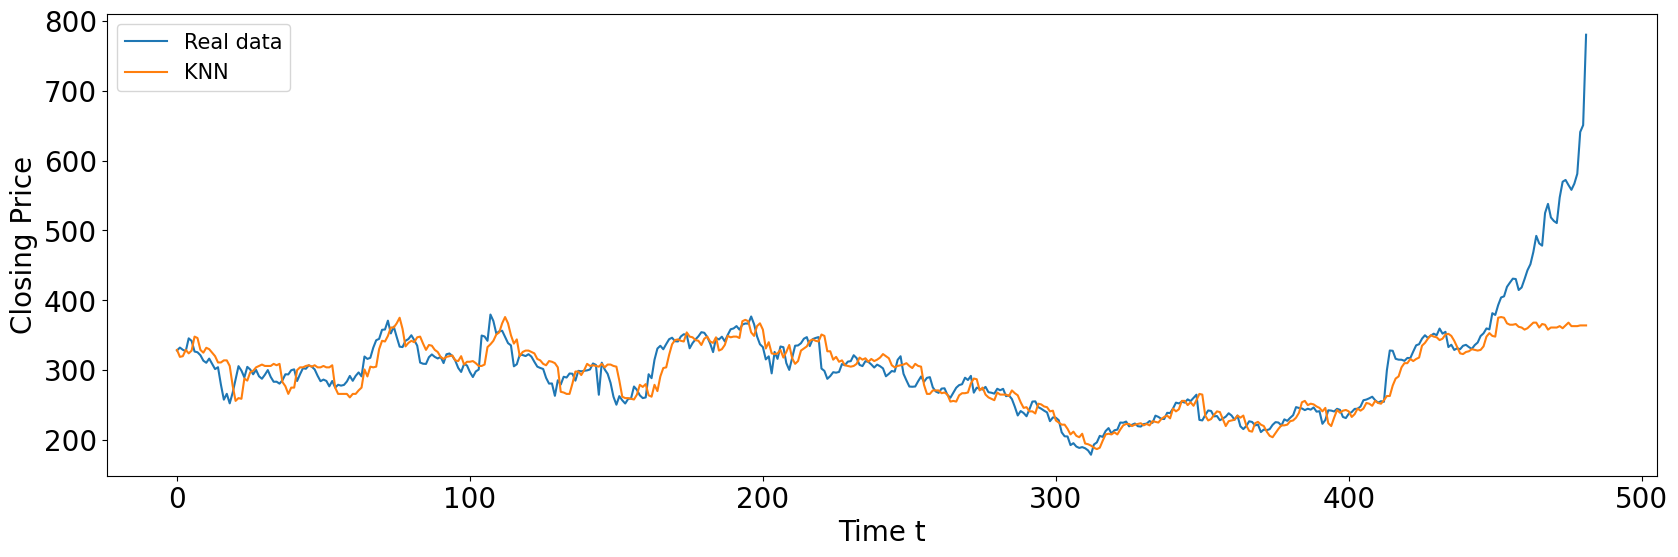

In [ ]:
# Visualization

fig1 = plt.figure(figsize=(20,6))
# plotting the result
# because the total number of test is data is high, so we just print the first 100 data
# y_test[0:100] get the first 100 data from y_test or real test data.
# y_pred_mlp is the prediction result from MLP
# y_pred_knn is the prediction result from KNN

plt.plot(y_test, label='Real data')
plt.plot(y_pred_knn, label='KNN')
# plt.plot(y_pred_dt, label='DT')
# plt.plot(y_pred_rf, label='RF')
# plt.plot(y_pred_mlp, label='MLP')

#title
# pyplot.title('First 100 Test Data')
# the x axis is timestamp, with interval 1 day
plt.xlabel('Time t', fontsize=20)
plt.ylabel('Closing Price', fontsize=20)
plt.legend(loc='upper left', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [ ]:
# Model Evaluation

# print out the RMSE , pearson correlation coefficient for MLP and KNN
# low RMSE is better
# high pearson correlation coefficient is better.
print('______________________')
print('MLP')
print('RMSE : %.3f' %rmse_mlp)
print('Pearson correlation coefficient: %.3f' %corr_mlp)
print('______________________')
print('KNN')
print('RMSE : %.3f' %rmse_knn)
print('Pearson correlation coefficient: %.3f' %corr_knn)
print('______________________')
print('DT')
print('RMSE : %.3f' %rmse_dt)
print('Pearson correlation coefficient: %.3f' %corr_dt)
print('______________________')
print('RF')
print('RMSE : %.3f' %rmse_rf)
print('Pearson correlation coefficient: %.3f' %corr_rf)

______________________
MLP
RMSE : 18.985
Pearson correlation coefficient: 0.968
______________________
KNN
RMSE : 45.187
Pearson correlation coefficient: 0.800
______________________
DT
RMSE : 47.492
Pearson correlation coefficient: 0.772
______________________
RF
RMSE : 44.963
Pearson correlation coefficient: 0.805


## Nomer 3


In [ ]:
# change data format
df_ori = df
df_ori['Date'] = pd.to_datetime(df_ori['Date'])
df_ori['Close'].iloc[:10]

,Close
0,23.889999
1,23.830000
2,21.959999
3,19.200001
4,16.110001
5,15.800000
6,17.459999
7,17.400000
8,17.049999
9,18.139999


In [ ]:
df_ori['Open'].iloc[:10]

,Open
0,19.000000
1,25.790001
2,25.000000
3,23.000000
4,20.000000
5,16.400000
6,16.139999
7,17.580000
8,17.950001
9,17.389999


In [ ]:
# Open + close jadi feature, close jadi target
df_X = df_ori[['Open', 'Close', 'Close']]
in_seq = df_X.astype(float).values
#out_seq = df_y.astype(float).values

#in_seq1 = in_seq.reshape(in_seq.shape[0], in_seq.shape[1])
#out_seq = out_seq.reshape((len(out_seq), 1))

#from numpy import hstack
#dataset = hstack((in_seq1, out_seq))

n_steps_in, n_steps_out = 7, 2
X, y = split_sequences(in_seq, n_steps_in, n_steps_out)

n_input = X.shape[1] * X.shape[2]
X = X.reshape((X.shape[0], n_input))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
X_train = stats_features(X_train)
X_test = stats_features(X_test)

In [ ]:
in_seq

array([[ 19.      ,  23.889999,  23.889999],
       [ 25.790001,  23.83    ,  23.83    ],
       [ 25.      ,  21.959999,  21.959999],
       ...,
       [632.419983, 640.809998, 640.809998],
       [640.      , 650.570007, 650.570007],
       [673.690002, 780.      , 780.      ]])

In [ ]:
X.shape

(2408, 14)

In [ ]:
X[0]

array([19.      , 23.889999, 25.790001, 23.83    , 25.      , 21.959999,
       23.      , 19.200001, 20.      , 16.110001, 16.4     , 15.8     ,
       16.139999, 17.459999])

In [ ]:
y[0]

np.float64(17.049999)

In [ ]:
# Dataframe from Time Series Analysis

df_new=df_ori[['Date', 'Open','Close']]
df_new.set_index('Date')

,Open,Close
Date,,
2010-06-29,19.000000,23.889999
2010-06-30,25.790001,23.830000
2010-07-01,25.000000,21.959999
2010-07-02,23.000000,19.200001
2010-07-06,20.000000,16.110001
...,...,...
2020-01-28,568.489990,566.900024
2020-01-29,575.690002,580.989990
2020-01-30,632.419983,640.809998


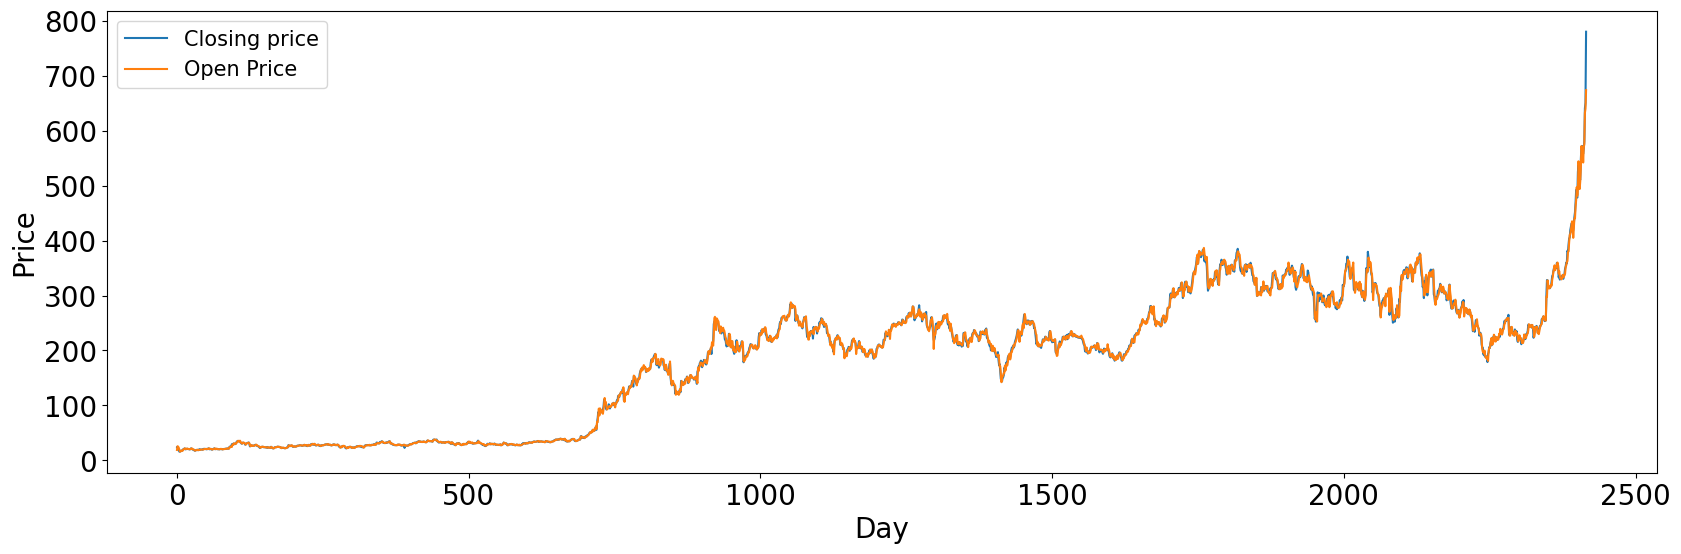

In [ ]:
# Visualization Total Bike Rental

fig1 = plt.figure(figsize=(20,6))
plt.plot(df_new['Close'], label='Closing price')
plt.plot(df_new['Open'], label='Open Price')
plt.xlabel('Day',  fontsize=20)
plt.ylabel('Price',  fontsize=20)
plt.legend(loc='upper left',  fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [ ]:
# Call the Machine Learning Model Function

#calling the function mlp.
#returning rmse, pearson correlation, and prediction output
rmse_mlp, corr_mlp, y_pred_mlp = mlp(X_train, X_test, y_train, y_test)

#calling the function knn
#returning rmse, pearson correlation, and prediction output
rmse_knn, corr_knn, y_pred_knn = knn(X_train, X_test, y_train, y_test)
rmse_dt, corr_dt, y_pred_dt = dt(X_train, X_test, y_train, y_test)

#rmse_svm, corr_svm, y_pred_svm = svm(X_train, X_test, y_train, y_test)
rmse_rf, corr_rf, y_pred_rf = rf(X_train, X_test, y_train, y_test)

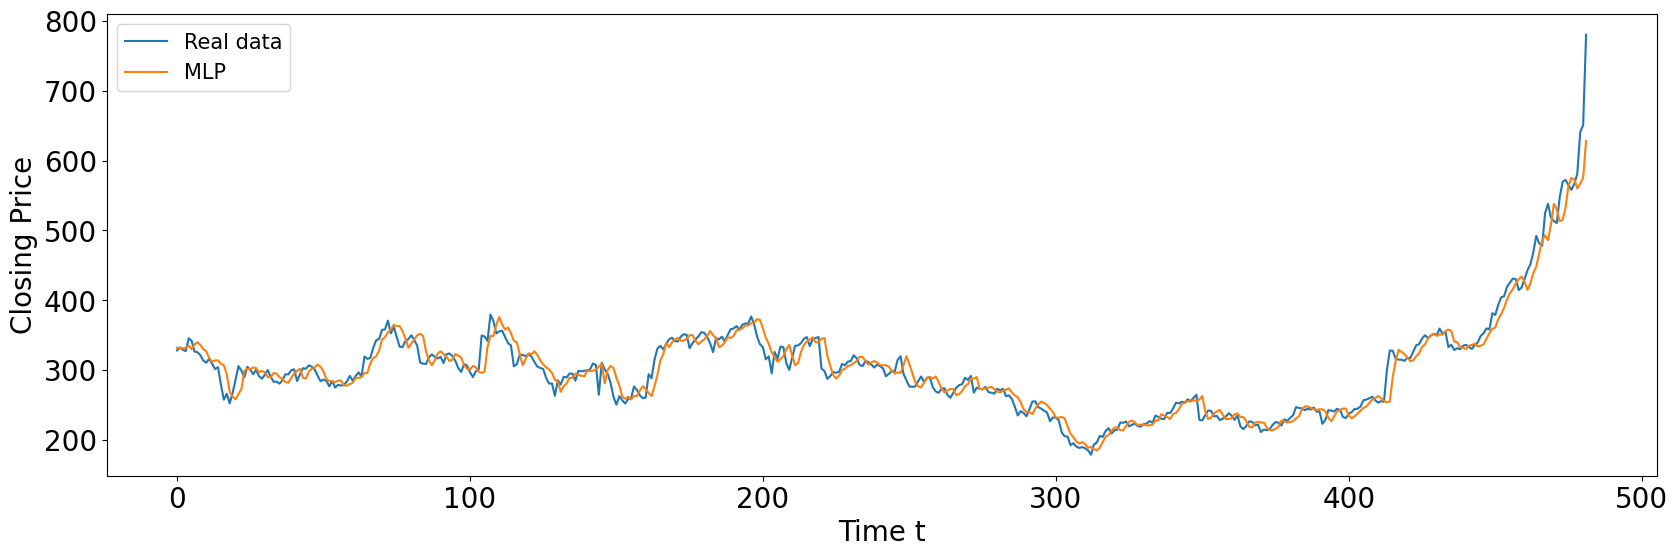

In [ ]:
# Visualization

fig1 = plt.figure(figsize=(20,6))
# plotting the result
# because the total number of test is data is high, so we just print the first 100 data
# y_test[0:100] get the first 100 data from y_test or real test data.
# y_pred_mlp is the prediction result from MLP
# y_pred_knn is the prediction result from KNN

plt.plot(y_test, label='Real data')
# plt.plot(y_pred_knn, label='KNN')
# plt.plot(y_pred_dt, label='DT')
# plt.plot(y_pred_rf, label='RF')
plt.plot(y_pred_mlp, label='MLP')

#title
# pyplot.title('First 100 Test Data')
# the x axis is timestamp, with interval 1 day
plt.xlabel('Time t', fontsize=20)
plt.ylabel('Closing Price', fontsize=20)
plt.legend(loc='upper left', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

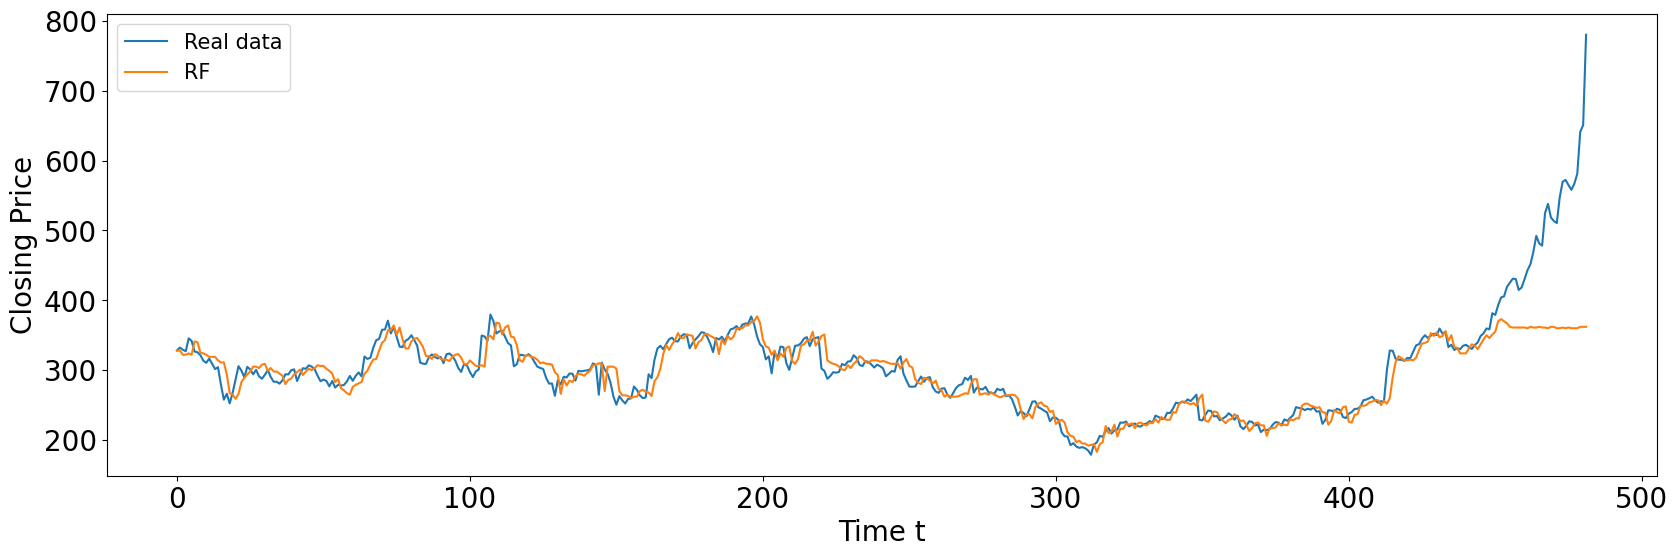

In [ ]:
# Visualization

fig1 = plt.figure(figsize=(20,6))
# plotting the result
# because the total number of test is data is high, so we just print the first 100 data
# y_test[0:100] get the first 100 data from y_test or real test data.
# y_pred_mlp is the prediction result from MLP
# y_pred_knn is the prediction result from KNN

plt.plot(y_test, label='Real data')
# plt.plot(y_pred_knn, label='KNN')
# plt.plot(y_pred_dt, label='DT')
plt.plot(y_pred_rf, label='RF')
# plt.plot(y_pred_mlp, label='MLP')

#title
# pyplot.title('First 100 Test Data')
# the x axis is timestamp, with interval 1 day
plt.xlabel('Time t', fontsize=20)
plt.ylabel('Closing Price', fontsize=20)
plt.legend(loc='upper left', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

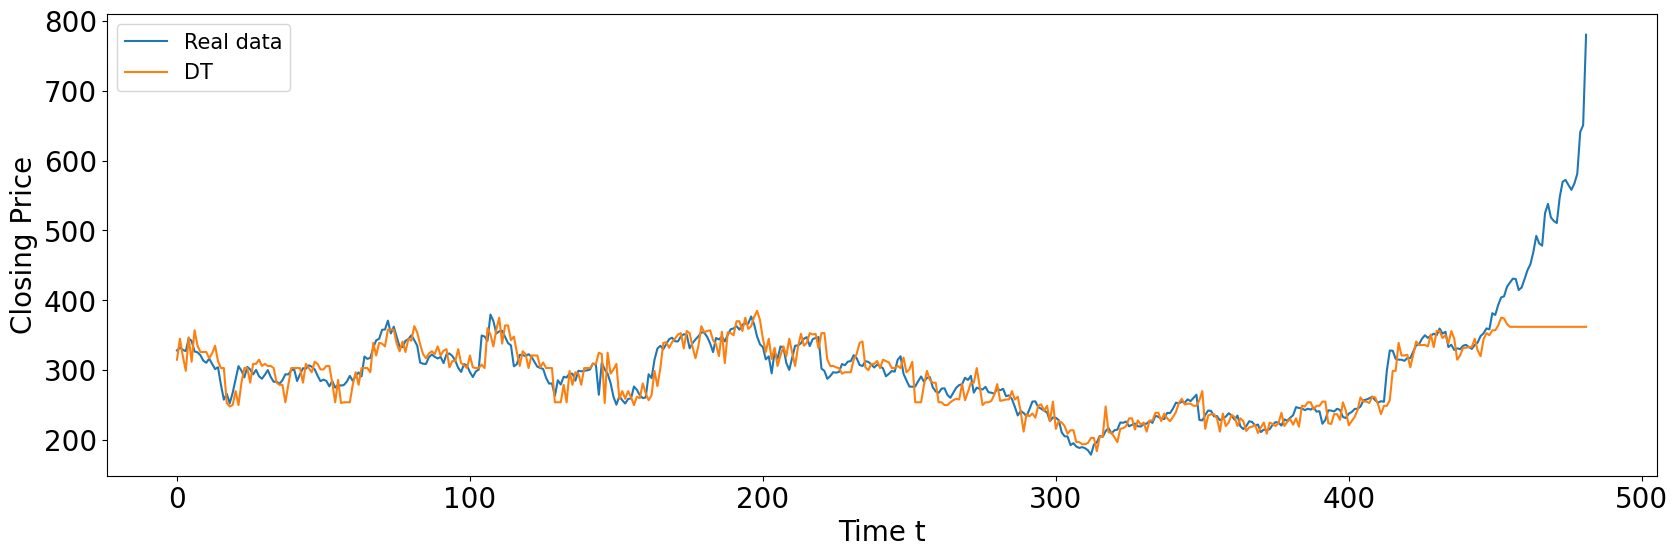

In [ ]:
# Visualization

fig1 = plt.figure(figsize=(20,6))
# plotting the result
# because the total number of test is data is high, so we just print the first 100 data
# y_test[0:100] get the first 100 data from y_test or real test data.
# y_pred_mlp is the prediction result from MLP
# y_pred_knn is the prediction result from KNN

plt.plot(y_test, label='Real data')
# plt.plot(y_pred_knn, label='KNN')
plt.plot(y_pred_dt, label='DT')
# plt.plot(y_pred_rf, label='RF')
# plt.plot(y_pred_mlp, label='MLP')

#title
# pyplot.title('First 100 Test Data')
# the x axis is timestamp, with interval 1 day
plt.xlabel('Time t', fontsize=20)
plt.ylabel('Closing Price', fontsize=20)
plt.legend(loc='upper left', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

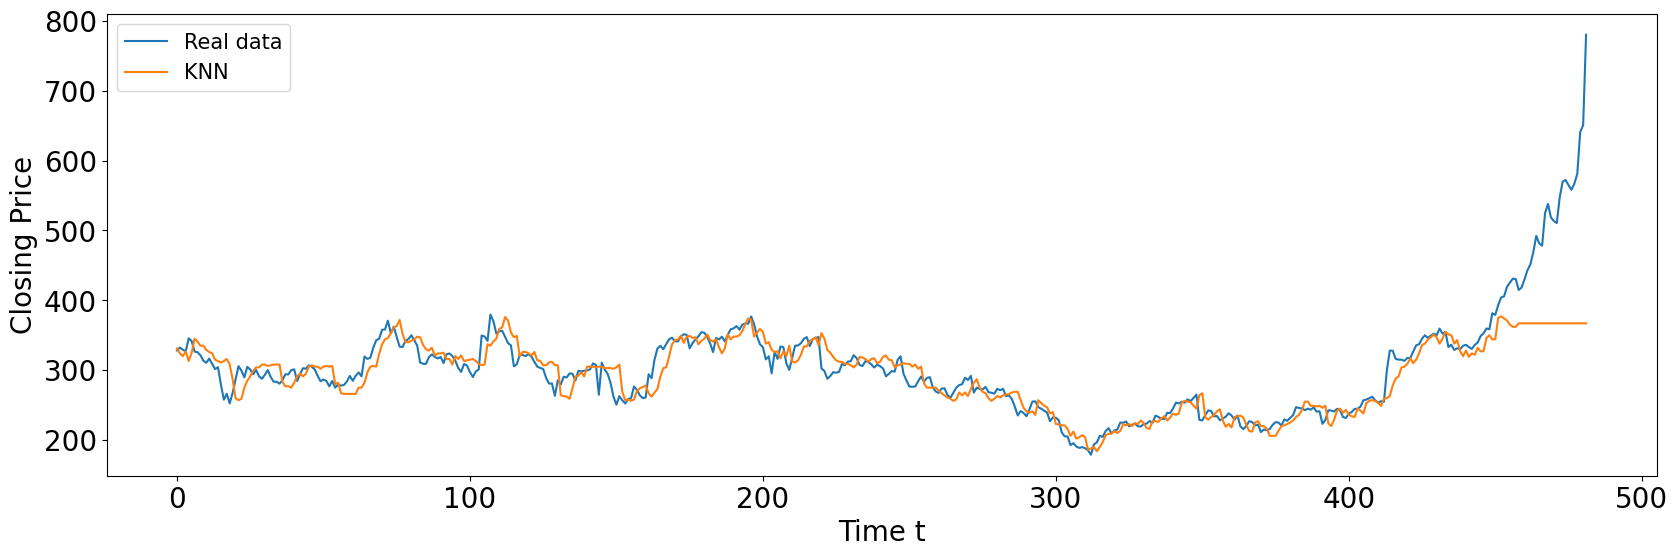

In [ ]:
# Visualization

fig1 = plt.figure(figsize=(20,6))
# plotting the result
# because the total number of test is data is high, so we just print the first 100 data
# y_test[0:100] get the first 100 data from y_test or real test data.
# y_pred_mlp is the prediction result from MLP
# y_pred_knn is the prediction result from KNN

plt.plot(y_test, label='Real data')
plt.plot(y_pred_knn, label='KNN')
# plt.plot(y_pred_dt, label='DT')
# plt.plot(y_pred_rf, label='RF')
# plt.plot(y_pred_mlp, label='MLP')

#title
# pyplot.title('First 100 Test Data')
# the x axis is timestamp, with interval 1 day
plt.xlabel('Time t', fontsize=20)
plt.ylabel('Closing Price', fontsize=20)
plt.legend(loc='upper left', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [ ]:
# Model Evaluation

# print out the RMSE , pearson correlation coefficient for MLP and KNN
# low RMSE is better
# high pearson correlation coefficient is better.
print('______________________')
print('MLP')
print('RMSE : %.3f' %rmse_mlp)
print('Pearson correlation coefficient: %.3f' %corr_mlp)
print('______________________')
print('KNN')
print('RMSE : %.3f' %rmse_knn)
print('Pearson correlation coefficient: %.3f' %corr_knn)
print('______________________')
print('DT')
print('RMSE : %.3f' %rmse_dt)
print('Pearson correlation coefficient: %.3f' %corr_dt)
print('______________________')
print('RF')
print('RMSE : %.3f' %rmse_rf)
print('Pearson correlation coefficient: %.3f' %corr_rf)

______________________
MLP
RMSE : 17.767
Pearson correlation coefficient: 0.970
______________________
KNN
RMSE : 44.660
Pearson correlation coefficient: 0.806
______________________
DT
RMSE : 45.408
Pearson correlation coefficient: 0.796
______________________
RF
RMSE : 44.691
Pearson correlation coefficient: 0.808
